# E-commerce Furniture Dataset 2024

- **Domain:** Finance Analytics  
- **Project Type:** Exploratory Data Analysis (EDA)  
- **Tools Used:** Excel, NumPy, Pandas, Matplotlib, Seaborn
- **Level:** Beginer

## **Introduction**
This project focuses on analyzing the E-commerce furniture Dataset 2024. This dataset comprises 2,000 entries scraped from AliExpress, 
detailing a variety of furniture products. It captures key sales metrics and product details, offering asnapshot of consumer purchasing 
patterns and market trends in the online furniture retail space.

## **Objectives**
- Analysing the number of furniture items sold based on product attributes such as productTitle, originalPrice, price, and tagText.
- Understand the Furniture Dataset
- Compare Price, Original Price and Items Sold
- Identify the trend over the months


## **Dataset Description**

The dataset contains E-commerce furniture Dataset 2024..  
It provides detailed information about furniture items sold (sold) based on product attributes such as productTitle, originalPrice, price, and tagText

### Key Columns

- **productTitle:** – The name of the furniture item.  
- **originalPrice:** – The original price of the item before any discounts. 
- **price:** – The current selling price of the item 
- **sold:** –  The number of units sold. 
- **tagText:** –  Additional tags associated with the item (e.g., "Free shipping").
  

The dataset is used to perform data cleaning, exploratory data analysis, and to understand number of furniture items sold (sold) based on product
attributes such as productTitle, originalPrice, price, and tagText in 2024.


# Step 1: Import Libraries and Load Data

In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\Sumathi\Downloads\ecommerce_furniture_dataset_2024.csv")


In [3]:
# Display all columns,rows and removes floating values have more than 2 values after decimal like 10.12345
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [4]:
#Showing 1st five Rows

data.head()

,Product_Title,Original_Price,Price,Sold,Tag_Text
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.4,39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1,Free shipping


# Step 2: Data Overview and Understanding
In this step, the dataset is explored to understand its structure, data types, and basic statistics. This helps identify missing values, incorrect data types, and gives an overall idea of the dataset before cleaning.

In [5]:
#displays the shape of the data set

data.shape

(2000, 5)

In [6]:
# Check basic information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Product_Title   2000 non-null   object
 1   Original_Price  487 non-null    object
 2   Price           2000 non-null   object
 3   Sold            2000 non-null   int64 
 4   Tag_Text        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


In [7]:
# statistical summary of numerical columns

data.describe()

,Sold
count,2000.00
mean,23.49
std,254.09
min,0.00
25%,1.00
50%,3.00
75%,9.00
max,10000.00


In [8]:
# column names

data.columns

Index(['Product_Title', 'Original_Price', 'Price', 'Sold', 'Tag_Text'], dtype='object')

In [9]:
data.dtypes

Product_Title     object
Original_Price    object
Price             object
Sold               int64
Tag_Text          object
dtype: object

# Step 3: Data Cleaning

In this step, the dataset is cleaned by handling missing values and fixing incorrect data types. Cleaning the data is important to ensure accurate analysis and meaningful insights.

In [10]:
#removes extra spaces or symbols on coloumn headings

[re.sub(r'[\s/]+', '_', x.strip()) for x in data.columns]

['Product_Title', 'Original_Price', 'Price', 'Sold', 'Tag_Text']

In [11]:
print("Missing values before cleaning:")
print(data.isnull().sum())   ## checking for missing values

Missing values before cleaning:
Product_Title        0
Original_Price    1513
Price                0
Sold                 0
Tag_Text             3
dtype: int64


In [12]:
print('Missing data %',round(635/data.shape[0]*100,2))

Missing data % 31.75


In [13]:
data.dropna(inplace = True)

In [14]:
print("Missing values after cleaning:")
data.isnull().sum()

Missing values after cleaning:


Product_Title     0
Original_Price    0
Price             0
Sold              0
Tag_Text          0
dtype: int64

In [15]:
data.drop_duplicates(inplace=True)

In [16]:
# Convert Original_Price, Price and Sold columns to numeric

data["Original_Price"] = pd.to_numeric(data["Original_Price"], errors="coerce")
data["Price"] = pd.to_numeric(data["Price"], errors="coerce")
data["Sold"] = pd.to_numeric(data["Sold"], errors="coerce")



In [17]:
data.dtypes

Product_Title      object
Original_Price    float64
Price             float64
Sold                int64
Tag_Text           object
dtype: object

# Final Cleaned Data

In [18]:
data.head()

,Product_Title,Original_Price,Price,Sold,Tag_Text
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1,Free shipping
5,"3 Pieces Patio Furniture Set, Outdoor Swivel G...",NaN,123.40,53,Free shipping
7,"Living Room Furniture, Modern 3-Piece Includin...",NaN,734.58,5,Free shipping
20,7-piece patio furniture set modular wicker out...,671.47,331.24,39,Free shipping


In [19]:
%matplotlib inline

# Step 4: Exploratory Data Analysis (EDA)

## EDA 1: Distribution of 'sold' values

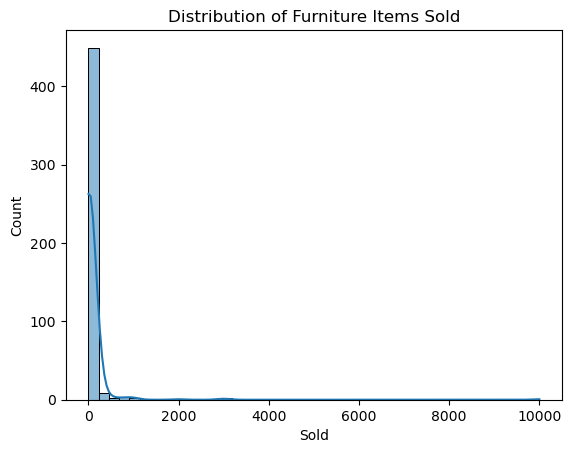

In [20]:
# Distribution of 'sold' values

sns.histplot(data['Sold'], kde=True)
plt.title('Distribution of Furniture Items Sold')
plt.savefig("Distribution of Furniture Items Sold")
plt.show()


**Conclusion:**
- The histogram shows the distribution of units sold for furniture products.
  
- Most furniture items have low sales volumes, with the majority of products selling only a small number of units.

- The distribution is highly right-skewed, meaning a few products achieve very high sales, while most remain low-selling.

- These high-selling products act as outliers, creating a long tail in the distribution

## EDA 2: Difference between sold and price

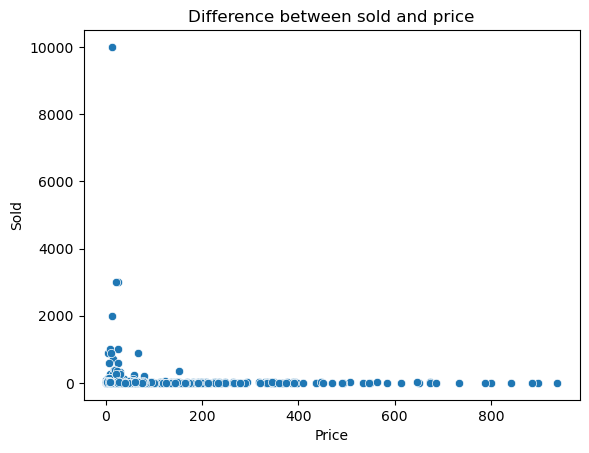

In [21]:
sns.scatterplot(x='Price', y='Sold', data=data)
plt.title("Difference between sold and price")
plt.savefig("Tag_Text.png", dpi=300, bbox_inches="tight")

**Conclusion:**

The scatter plot shows the relationship between Price and Units Sold. Most data points are concentrated at low price values, where the number of units sold varies widely. This suggests that lower-priced products tend to sell more, while higher-priced products generally have very low sales volume.

## EDA 3: distribution and relationship between Price and Units Sold.

In [23]:
filtered_df = data[data['Tag_Text'] == 'Free shipping']

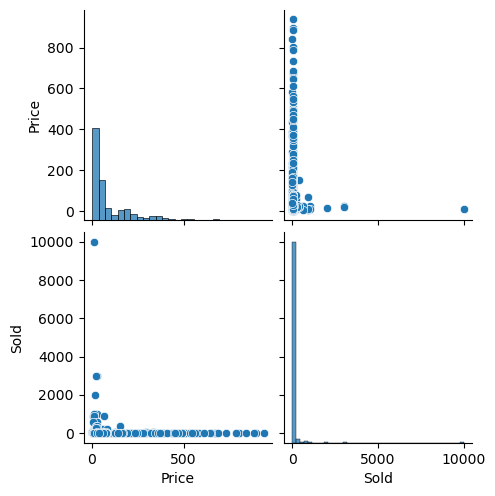

In [24]:
sns.pairplot(filtered_df[['Price', 'Sold']])
plt.savefig("Sold & Price.png")

**Conclusion:**

The pair plot shows the distribution and relationship between Price and Units Sold.

The histogram for Price indicates that most products are concentrated in the low-price range, with only a few high-priced items.

The histogram for Sold shows that the majority of products have low sales volume, while only a small number of items are sold in very large quantities (outliers).

The scatter plot suggests an inverse relationship between price and sales:
lower-priced products tend to sell more, whereas higher-priced products generally have fewer units sold.

## EDA 4: Relationship between Price, Original Price and Items Sold

In [25]:
data['Original_Price'] = data['Original_Price'].astype(str).str.replace(r'[₹$,]', '', regex=True).astype(float)
data['Price'] = data['Price'].astype(str).str.replace(r'[₹$,]', '', regex=True).astype(float)


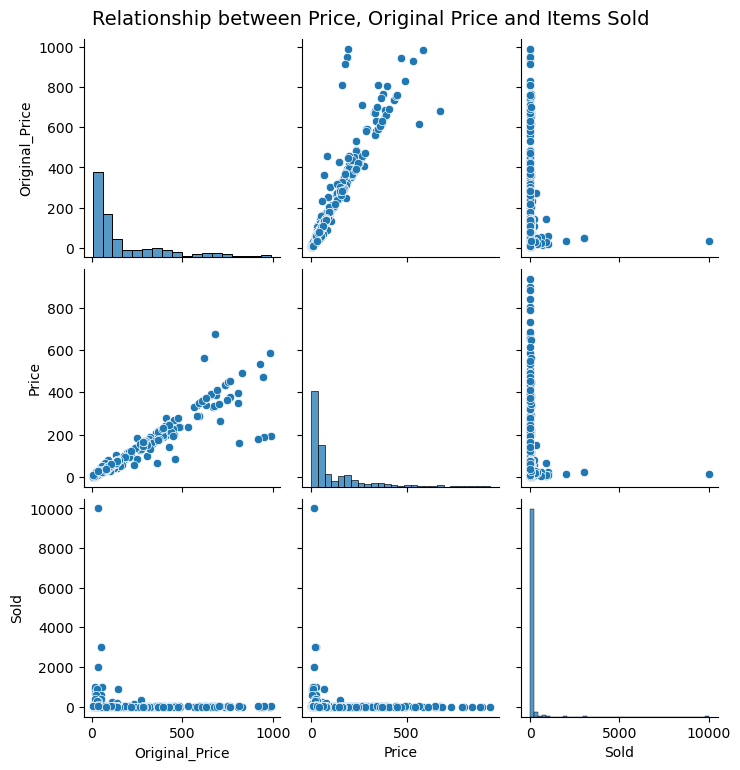

In [26]:
# Plot the relationship between originalPrice, price and sold
g=sns.pairplot(data, vars=['Original_Price', 'Price', 'Sold'],
kind='scatter')
g.fig.suptitle(
    'Relationship between Price, Original Price and Items Sold',
    y=1.02, fontsize=14)
g.savefig("price_relationship_pairplot.png")
plt.show()

**Conclusion:**  

- Original Price and Selling Price show a strong positive correlation, meaning higher original-priced products tend to have higher selling prices.

- The distribution of prices is highly right-skewed, with most products priced in the lower range and a few very expensive outliers.

- Units Sold is also heavily skewed, where most products have low sales, while a small number of products achieve extremely high sales volumes.

- There is no clear strong relationship between price and units sold, suggesting that sales depend on factors beyond pricing alone, such as product demand, brand value, or promotions.

- Several outliers are present in both price and sales, indicating exceptional products with unusually high price or demand.

## EDA 5: Distribution of Tag_Text

In [27]:
# Replace all values except 'Free shipping' and '+Shipping: $5.09' with 'others'

In [28]:
data['Tag_Text'] = data['Tag_Text'].apply(lambda x: x if x in ['Free shipping', '+Shipping: $5.09'] else 'others')

In [29]:
print(data['Tag_Text'].value_counts())

Tag_Text
Free shipping    468
others             2
Name: count, dtype: int64


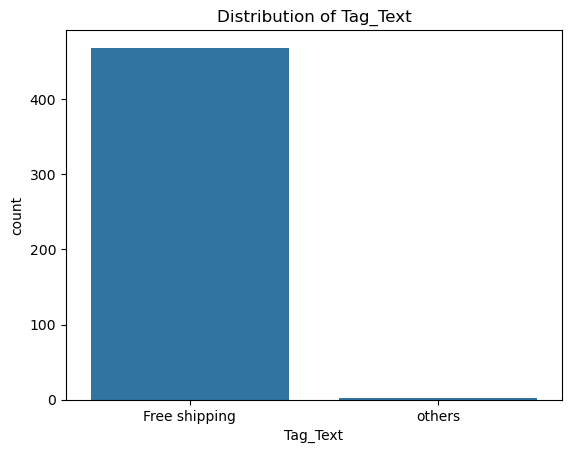

In [30]:
sns.countplot(x='Tag_Text',data=data)
plt.title("Distribution of Tag_Text")
plt.savefig("Tag_Text.png")

**Conclusions:**

- Free shipping dominates the dataset, appearing on the vast majority of products.

- The “others” tag category occurs very rarely, indicating that alternative shipping or promotional tags are minimal.

- This suggests that free shipping is the standard offer, likely used as a primary strategy to attract customers.

## EDA 6: Distribution of Price

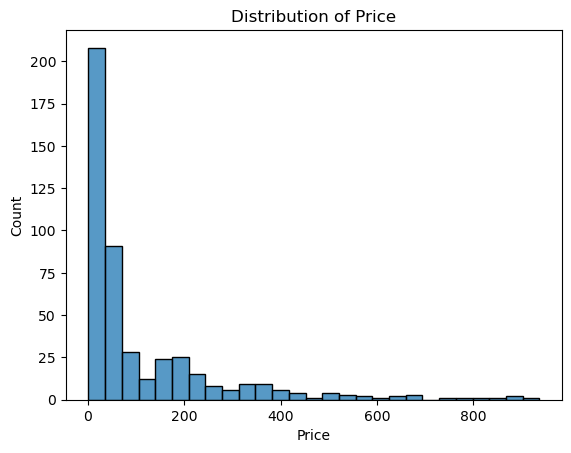

In [31]:
sns.histplot(data['Price'])
plt.title("Distribution of Price")
plt.savefig("Price.png")


**Conclusions:**

- Most products are concentrated in the lower price range, indicating that affordable items dominate the catalog.

- The distribution is highly right-skewed, meaning only a few products are priced very high.

- A small number of expensive items create a long tail, suggesting the presence of premium or high-value products.

- Overall, the dataset contains many low- to mid-priced products with limited high-priced outliers.

## EDA 7: Difference between sold and price

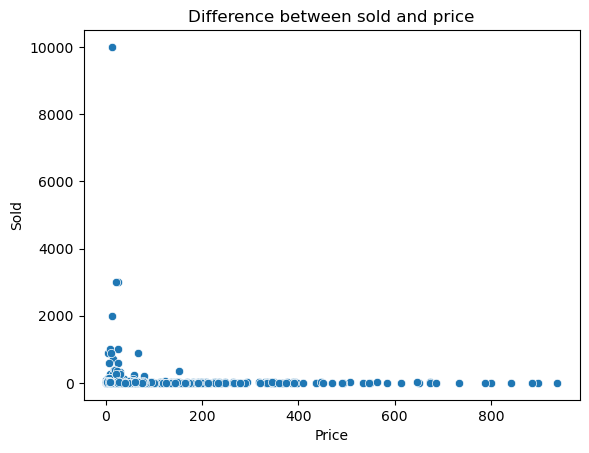

In [44]:
sns.scatterplot(x='Price', y='Sold', data=data)
plt.title("Difference between sold and price")
plt.savefig("Tag_Text.png", dpi=300, bbox_inches="tight")

**Conclusion:**

The scatter plot illustrates the relationship between Price and Units Sold. Most points are clustered at the lower price range, where sales volumes vary greatly. This indicates that low-priced products tend to achieve higher sales, while products with higher prices generally record very low units sold.

## EDA 8: Relationship between product price and units sold

In [33]:
filtered_df = data[data['Tag_Text'] == 'Free shipping']

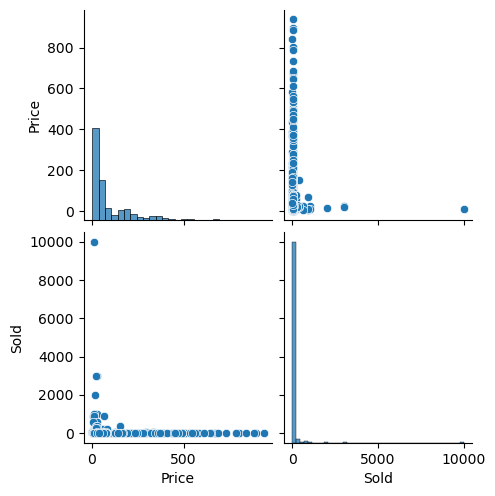

In [34]:
sns.pairplot(filtered_df[['Price', 'Sold']])
plt.savefig("Sold & Price.png")

**Conclusion:**
- The plot shows the relationship between product price and units sold, along with their individual distributions.
- Most products are priced in the lower range, as seen from the heavily right-skewed price distribution.

- Units sold are also highly skewed, where most products have low sales, while a few products achieve extremely high sales volumes.

- There is no strong direct correlation between price and sales, meaning higher-priced products do not necessarily sell more or less consistently.

- Several outliers exist, including a few expensive products with low sales and a few low-priced products with exceptionally high demand.

## EDA 9: Percentage of Products Providing Free Shipping

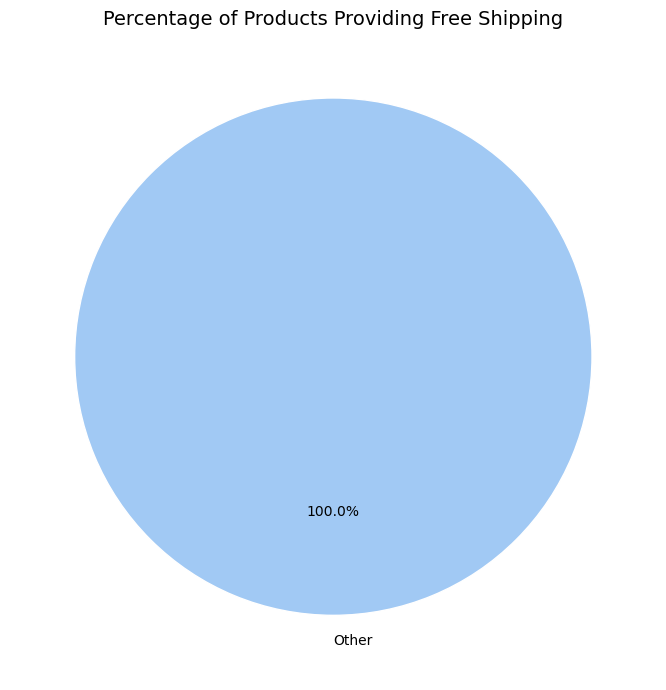

In [38]:
# Step 1: Create Shipping Type column
data["Shipping_Type"] = data["Tag_Text"].apply(
    lambda x: "Free Shipping" if "Free" in str(x) else "Other"
)

# Step 2: Count values
shipping_counts = data["Shipping_Type"].value_counts()

# Step 3: Plot Pie Chart with palette colors
colors = sns.color_palette("pastel")

plt.figure(figsize=(7,7))

plt.pie(
    shipping_counts,
    labels=shipping_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Percentage of Products Providing Free Shipping", fontsize=14)

# Step 4: Save the figure
plt.tight_layout()
plt.savefig("free_shipping_percentage.png", dpi=300)

# Step 5: Show plot
plt.show()


**Conclusion:**

- An overwhelming majority of products (99.6%) provide Free Shipping, indicating that free delivery is the standard offering in this dataset.

- Only a very small fraction of products (0.4%) fall under the Other shipping category.

## EDA 10:  Overall Sales Contribution of Top Product Categories 

C:\Users\Sumathi\AppData\Local\Temp\ipykernel_26096\3517527887.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


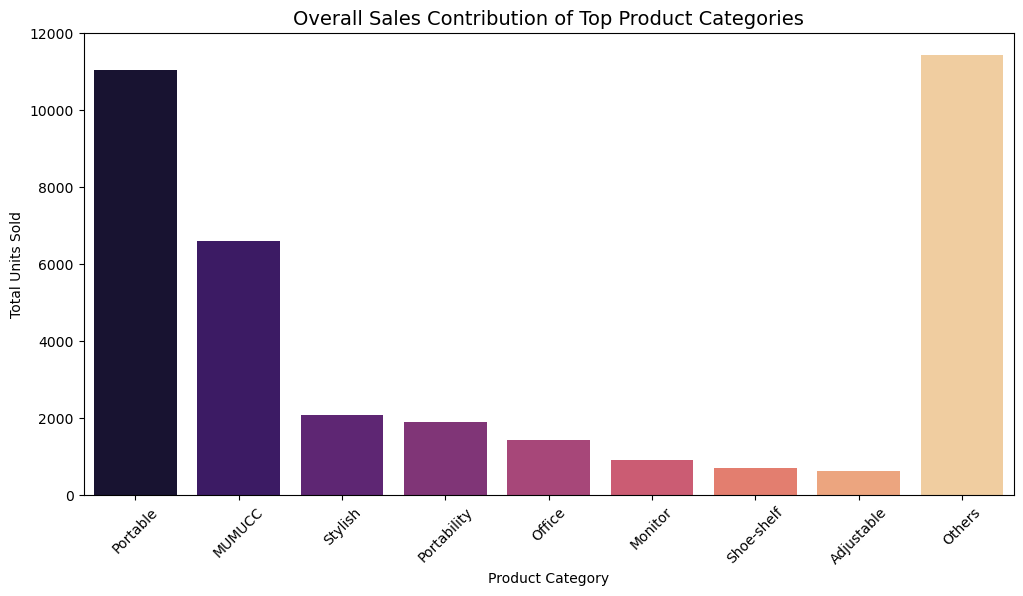

In [40]:
# Step 1: Create Category from first word in Product_Title
data["Category"] = data["Product_Title"].str.split().str[0]

# Step 2: Calculate total units sold per Category
category_sales = (
    data.groupby("Category")["Sold"]
    .sum()
    .sort_values(ascending=False)
)

# Step 3: Take Top 8 categories and group rest as "Others"
top_n = 8
top_categories = category_sales.head(top_n)
others = category_sales.iloc[top_n:].sum()

final_sales = top_categories.copy()
final_sales["Others"] = others

# Step 4: Convert to DataFrame for Seaborn
final_df = final_sales.reset_index()
final_df.columns = ["Category", "Total_Sales"]

# Step 5: Plot Bar Chart with Palette
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_df,
    x="Category",
    y="Total_Sales",
    palette="magma"
)

# Step 6: Add chart title and labels
plt.title("Overall Sales Contribution of Top Product Categories", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)

# Step 7: Save Figure

plt.savefig("top_category_sales_contribution.png", dpi=300)

# Step 8: Show Plot
plt.show()


**Conclusions:**

- A few categories such as Portable and MUMUCC contribute the highest number of units sold, indicating strong customer demand for these product types.

- The “Others” category represents a large combined share, showing that many smaller or less frequent categories together account for a significant portion of overall sales.

- Remaining categories such as Stylish, Portability, Office, Monitor, Shoe-shelf, and Adjustable contribute comparatively smaller sales volumes.

## EDA 11: Discounted vs Non-Discounted Products Sales

C:\Users\Sumathi\AppData\Local\Temp\ipykernel_26096\71337922.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


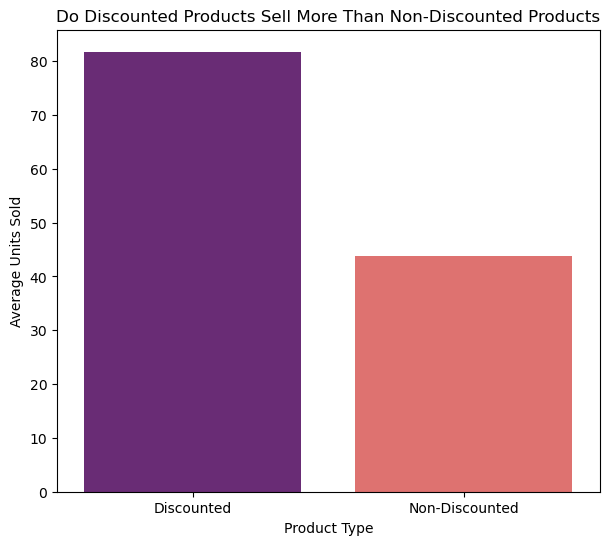

In [41]:
# Step 1: Create Discount column
# Discount exists only if Original_Price > Price
data["Discounted"] = data["Original_Price"] > data["Price"]

# Step 2: Replace True/False with Labels
data["Discount_Status"] = data["Discounted"].replace({
    True: "Discounted",
    False: "Non-Discounted"
})

# Step 3: Calculate average units sold for both groups
avg_sales = data.groupby("Discount_Status")["Sold"].mean().reset_index()

# Step 4: Plot bar chart with palette
plt.figure(figsize=(7,6))

sns.barplot(
    data=avg_sales,
    x="Discount_Status",
    y="Sold",
    palette="magma"
)

# Step 5: Add labels and title
plt.title("Do Discounted Products Sell More Than Non-Discounted Products", fontsize=12)
plt.xlabel("Product Type")
plt.ylabel("Average Units Sold")

# Step 6: Save the figure

plt.savefig("discounted_vs_nondiscounted_sales.png", dpi=300)

# Step 7: Show plot
plt.show()


**Conclusion:**

- Both categories show very similar sales performance.

- Non-discounted products have a slightly higher average units sold compared to discounted products. Other than price reduction (such as product demand, quality, or brand value) may have a stronger influence on customer purchases.

## EDA 12: Top 10 Revenue-Generating Products

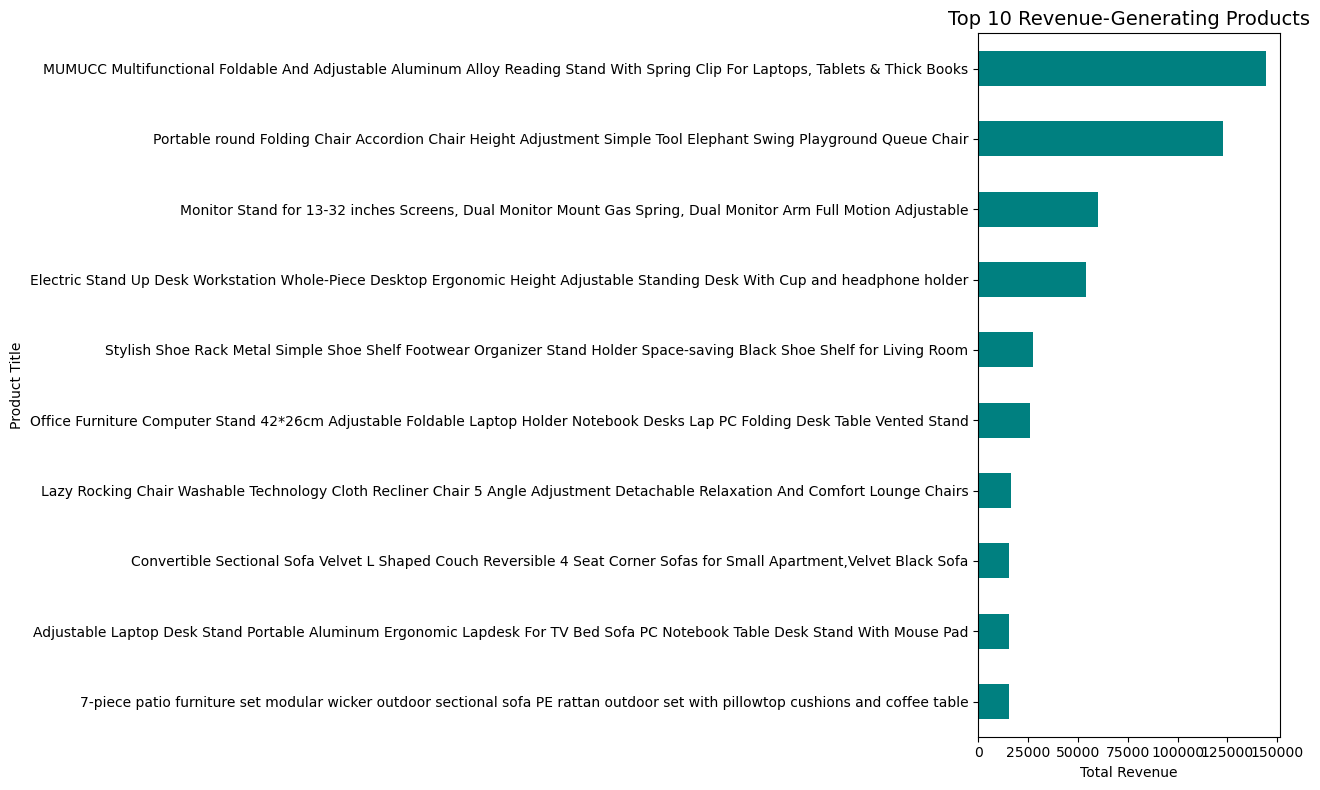

In [42]:
# Step 1: Create Revenue column
data["Revenue"] = data["Price"] * data["Sold"]

# Step 2: Get Top 10 highest revenue products
top10_revenue = (
    data.groupby("Product_Title")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Step 3: Reverse order for horizontal bar chart
top10_revenue = top10_revenue.sort_values()

# Step 4: Plot Horizontal Bar Chart
plt.figure(figsize=(13, 8))
top10_revenue.plot(kind="barh", color="teal")

plt.title("Top 10 Revenue-Generating Products", fontsize=14)
plt.xlabel("Total Revenue")
plt.ylabel("Product Title")

# Step 5: Save Figure
plt.tight_layout()
plt.savefig("top_10_revenue_products.png", dpi=300)

plt.show()


**Conclusion:** 

The horizontal bar shows that the top 10 revenue generating products

1. MUMUCC multifunctional foldable and adjustable aluminum alloy reading stand with spring clip for laptops, tables & thick books

2. Portable round folding chair accordion chair height adjustment simple tool elephant swing playground queue chair are the top 2 revenue generating products

# Step 5: Generate Report

Summary The Ecommerce Furniture dataset was analyzed to identify key trends and insights. The data cleaning process involved handling missing values, correcting data types, and removing duplicates. The project successfully analyzed Ecommerce Furniture data using EDA  